# EMG Autoencoder — Vanilla v6 — Autoencoder for Recons v3 → `_latent_v3.hdf5` per session


## 1. Install Dependencies
Install required packages (`h5py`, `unidecode`) if not already present.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'h5py', 'unidecode'], check=True)

CompletedProcess(args=['/Users/jonathangray/miniconda3/envs/e219/bin/python', '-m', 'pip', 'install', '-q', 'h5py', 'unidecode'], returncode=0)

## 2. Imports & Device Setup
Import standard libraries, PyTorch, matplotlib, and project utilities. Detect CPU/GPU device.

In [2]:
import sys
sys.path.insert(0, '..')

import h5py
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

from emg2qwerty.charset import charset as get_charset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHARSET = get_charset()
print('device:', device)

device: cpu


## 3. Model Architecture & Helpers
Define bandpass filter, the vanilla autoencoder (encoder/decoder), and training utilities.

In [3]:
from scipy.signal import butter, sosfiltfilt

def bandpass(data, lo=0.0001, hi=500, fs=2000, order=4):
    sos = butter(order, [lo, hi], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, data, axis=0).astype(np.float32)


class VanillaConv1dAE(nn.Module):
    def __init__(self, n_channels=32, latent_dim=256, window=512):
        super().__init__()
        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32,  5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32,         64,  5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(64,         128, 5, stride=2, padding=2), nn.ReLU(),
        )
        with torch.no_grad():
            self._enc_len = self.encoder_cnn(
                torch.zeros(1, n_channels, window)).shape[-1]
        self.fc_enc = nn.Linear(128 * self._enc_len, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 128 * self._enc_len)
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(128, 64,         4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(64,  32,         4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32,  n_channels, 4, stride=2, padding=1),
        )

    def encode(self, x):
        h = self.encoder_cnn(x.transpose(1, 2))
        return self.fc_enc(h.flatten(1))

    def decode(self, z):
        h = self.fc_dec(z).view(z.size(0), 128, self._enc_len)
        return self.decoder_cnn(h).transpose(1, 2)

    def forward(self, x):
        return self.decode(self.encode(x))


class EMGDataset(Dataset):
    def __init__(self, windows):
        self.w = torch.tensor(windows, dtype=torch.float32)
    def __len__(self): return len(self.w)
    def __getitem__(self, i): return self.w[i]

## 4. Train One Autoencoder Per Session → Save `_latent_v3.hdf5`
For each raw HDF5 session file: normalize EMG, train autoencoder, save latent representations and model weights.

In [5]:
SESSION_DIR = Path('89335547')
raw_files   = sorted([
    f for f in SESSION_DIR.glob('*.hdf5')
    if 'latent' not in f.name and '500hz' not in f.name
])

WINDOW     = 128
STRIDE     = 32
LATENT_DIM = 256
NUM_EPOCHS = 80

print(f'Found {len(raw_files)} sessions — training one AE each\n')

for idx, path in enumerate(raw_files):
    out_latent = path.with_name(path.stem + '_latent_v3.hdf5')
    out_model  = path.with_name(path.stem + '_ae_v3.pt')

    print(f'[{idx+1}/{len(raw_files)}] {path.name}')

    # Load + preprocess
    with h5py.File(path, 'r') as f:
        ts        = f['emg2qwerty/timeseries']
        raw_time  = ts['time'][:]
        emg_left  = ts['emg_left'][:].astype(np.float32)
        emg_right = ts['emg_right'][:].astype(np.float32)
        keystrokes = json.loads(f['emg2qwerty'].attrs['keystrokes'])

    emg    = np.concatenate([emg_left, emg_right], axis=1)   # (N, 32)
    s_mean = emg.mean(0, keepdims=True)
    s_std  = emg.std(0,  keepdims=True) + 1e-8
    emg_n  = bandpass((emg - s_mean) / s_std)

    starts    = np.arange(0, len(emg_n) - WINDOW + 1, STRIDE)
    win_times = raw_time[starts]
    windows   = np.stack([emg_n[s:s + WINDOW] for s in starts]).astype(np.float32)
    print(f'  windows: {len(windows):,}')

    # Train
    n_train  = int(0.8 * len(windows))
    train_ds = EMGDataset(windows[:n_train])
    val_ds   = EMGDataset(windows[n_train:])
    train_ld = DataLoader(train_ds, batch_size=256, shuffle=True,  drop_last=True)
    val_ld   = DataLoader(val_ds,   batch_size=256, shuffle=False)

    ae    = VanillaConv1dAE(latent_dim=LATENT_DIM, window=WINDOW).to(device)
    opt   = torch.optim.Adam(ae.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS, eta_min=5e-4)

    for epoch in range(NUM_EPOCHS):
        ae.train()
        for x in train_ld:
            x = x.to(device)
            loss = F.mse_loss(ae(x), x)
            opt.zero_grad(); loss.backward(); opt.step()

        ae.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x in val_ld:
                x = x.to(device)
                val_loss += F.mse_loss(ae(x), x).item()
        sched.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  epoch {epoch+1:2d}/{NUM_EPOCHS}  val={val_loss/len(val_ld):.5f}')

    # Extract latents
    ae.eval()
    all_ld  = DataLoader(EMGDataset(windows), batch_size=256, shuffle=False)
    latents = []
    with torch.no_grad():
        for x in all_ld:
            latents.append(ae.encode(x.to(device)).cpu().numpy())
    latent = np.concatenate(latents, axis=0)   # (T, 256)

    # Save latent HDF5
    with h5py.File(out_latent, 'w') as out_f:
        grp = out_f.create_group('emg2qwerty')
        with h5py.File(path, 'r') as src_f:
            for key, val in src_f['emg2qwerty'].attrs.items():
                grp.attrs[key] = val
        grp.attrs['latent_dim']     = LATENT_DIM
        grp.attrs['latent_rate_hz'] = 2000 / STRIDE
        grp.attrs['window_samples'] = WINDOW
        grp.attrs['stride_samples'] = STRIDE
        grp.create_dataset('norm_mean', data=s_mean.astype(np.float32))
        grp.create_dataset('norm_std',  data=s_std.astype(np.float32))
        grp.create_dataset('latent', data=latent.astype(np.float32), compression='gzip')
        grp.create_dataset('time',   data=win_times.astype(np.float64), compression='gzip')

    # Save model weights
    torch.save({
        'model_state_dict': ae.state_dict(),
        'mean': s_mean, 'std': s_std,
        'window': WINDOW, 'latent_dim': LATENT_DIM,
    }, out_model)

    print(f'  → {out_latent.name}  latent={latent.shape}\n')

print('All sessions done.')

Found 18 sessions — training one AE each

[1/18] 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
  windows: 74,275
  epoch  1/80  val=0.69535
  epoch  5/80  val=0.32640
  epoch 10/80  val=0.20251
  epoch 15/80  val=0.15865
  epoch 20/80  val=0.13517
  epoch 25/80  val=0.12143
  epoch 30/80  val=0.11610
  epoch 35/80  val=0.11287
  epoch 40/80  val=0.10963
  epoch 45/80  val=0.10739
  epoch 50/80  val=0.11290
  epoch 55/80  val=0.10344
  epoch 60/80  val=0.10388
  epoch 65/80  val=0.10245
  epoch 70/80  val=0.10185
  epoch 75/80  val=0.10224
  epoch 80/80  val=0.10123
  → 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_latent_v3.hdf5  latent=(74275, 256)

[2/18] 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
  windows: 68,037
  epoch  1/80  val=0.65890
  epoch  5/80  val=0.38685
  epoch 10/80  val=0.20358
  epoch 15/80  val=0.15424
  epoch 20/80  val=0.12630
  epoch 25/80  va

## 5. Reconstruct EMG from a `_latent_v3.hdf5` File
Load saved autoencoder weights and decode latent representations back to EMG signal for a single session.

Loaded 89335547/2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_ae_v3.pt
Decoded 55954 windows from 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_latent_v3.hdf5


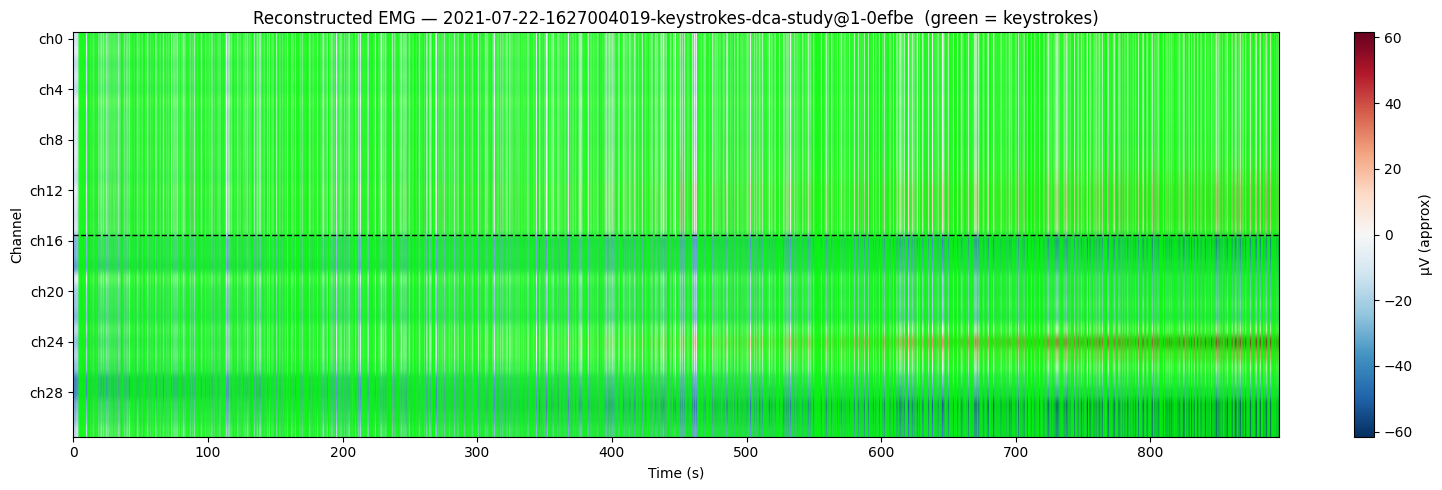

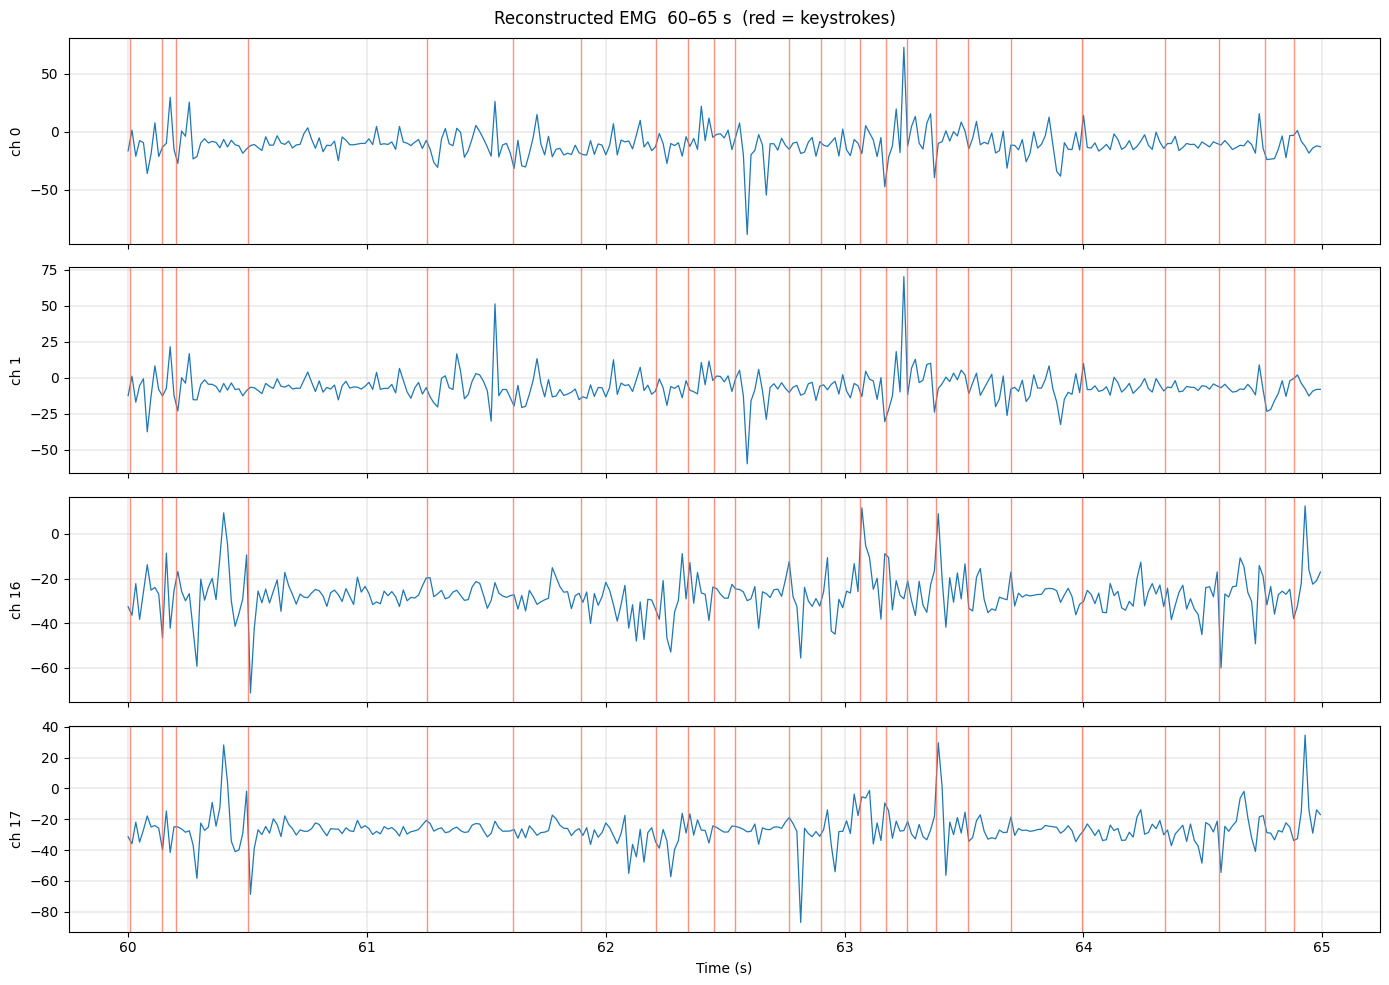

In [8]:
import h5py, json
import numpy as np
import torch
from torch import nn
from pathlib import Path
import matplotlib.pyplot as plt

# Reload model (works standalone without re-running training)
WEIGHTS_PATH = Path('89335547/2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_ae_v3.pt')

class VanillaConv1dAE(nn.Module):
    def __init__(self, n_channels=32, latent_dim=256, window=512):
        super().__init__()
        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32,  5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32,         64,  5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(64,         128, 5, stride=2, padding=2), nn.ReLU(),
        )
        with torch.no_grad():
            self._enc_len = self.encoder_cnn(torch.zeros(1, n_channels, window)).shape[-1]
        self.fc_enc = nn.Linear(128 * self._enc_len, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 128 * self._enc_len)
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(128, 64,         4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(64,  32,         4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32,  n_channels, 4, stride=2, padding=1),
        )
    def decode(self, z):
        h = self.fc_dec(z).view(z.size(0), 128, self._enc_len)
        return self.decoder_cnn(h).transpose(1, 2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt   = torch.load(WEIGHTS_PATH, map_location=device, weights_only=False)  # ← fixed
ae_r   = VanillaConv1dAE(latent_dim=ckpt['latent_dim'], window=ckpt['window']).to(device)
ae_r.load_state_dict(ckpt['model_state_dict'])
ae_r.eval()
print(f'Loaded {WEIGHTS_PATH}')

LATENT_FILE = Path('89335547/2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_latent_v3.hdf5')

with h5py.File(LATENT_FILE) as f:
    latents    = f['emg2qwerty/latent'][:]
    times      = f['emg2qwerty/time'][:]
    keystrokes = json.loads(f['emg2qwerty'].attrs['keystrokes'])
    norm_mean  = f['emg2qwerty/norm_mean'][:]
    norm_std   = f['emg2qwerty/norm_std'][:]

t0    = times[0]
rel_t = times - t0

BATCH = 512
recons_norm = []
with torch.no_grad():
    for i in range(0, len(latents), BATCH):
        z   = torch.tensor(latents[i:i+BATCH], dtype=torch.float32).to(device)
        rec = ae_r.decode(z).cpu().numpy()
        recons_norm.append(rec)
recons_norm = np.concatenate(recons_norm, axis=0)

recons = recons_norm * norm_std + norm_mean
mid    = recons.shape[1] // 2          # ← fixed (dynamic, avoids IndexError)
centre = recons[:, mid, :]
print(f'Decoded {len(recons)} windows from {LATENT_FILE.name}')

fig, ax = plt.subplots(figsize=(16, 5))
vmax = np.percentile(np.abs(centre), 98)
im = ax.imshow(centre.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               extent=[rel_t[0], rel_t[-1], 31.5, -0.5], origin='upper')
for k in keystrokes:
    kt = k['start'] - t0
    if 0 <= kt <= rel_t[-1]:
        ax.axvline(kt, color='lime', lw=0.4, alpha=0.5)
plt.colorbar(im, ax=ax, label='μV (approx)')
ax.axhline(15.5, color='k', lw=1, ls='--')
ax.set_yticks(range(0, 32, 4))
ax.set_yticklabels([f'ch{i}' for i in range(0, 32, 4)])
ax.set_xlabel('Time (s)');  ax.set_ylabel('Channel')
ax.set_title(f'Reconstructed EMG — {LATENT_FILE.name[:50]}  (green = keystrokes)')
plt.tight_layout(); plt.show()

T_START, T_END = 60, 65
CH_SHOW = [0, 1, 16, 17]
win_mask = (rel_t >= T_START) & (rel_t <= T_END)
ks_in    = [k for k in keystrokes if T_START <= k['start'] - t0 <= T_END]

fig, axes = plt.subplots(len(CH_SHOW), 1, figsize=(14, 2.5 * len(CH_SHOW)), sharex=True)
for ax, ch in zip(axes, CH_SHOW):
    ax.plot(rel_t[win_mask], centre[win_mask, ch], lw=0.9)
    for k in ks_in:
        ax.axvline(k['start'] - t0, color='tomato', lw=1.0, alpha=0.7)
    ax.set_ylabel(f'ch {ch}'); ax.grid(True, lw=0.3)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Reconstructed EMG  {T_START}–{T_END} s  (red = keystrokes)')
plt.tight_layout(); plt.show()


## 6. Overlay: Reconstructed vs Raw EMG
Plot reconstructed EMG overlaid on raw signal to visually assess reconstruction quality for a single session.

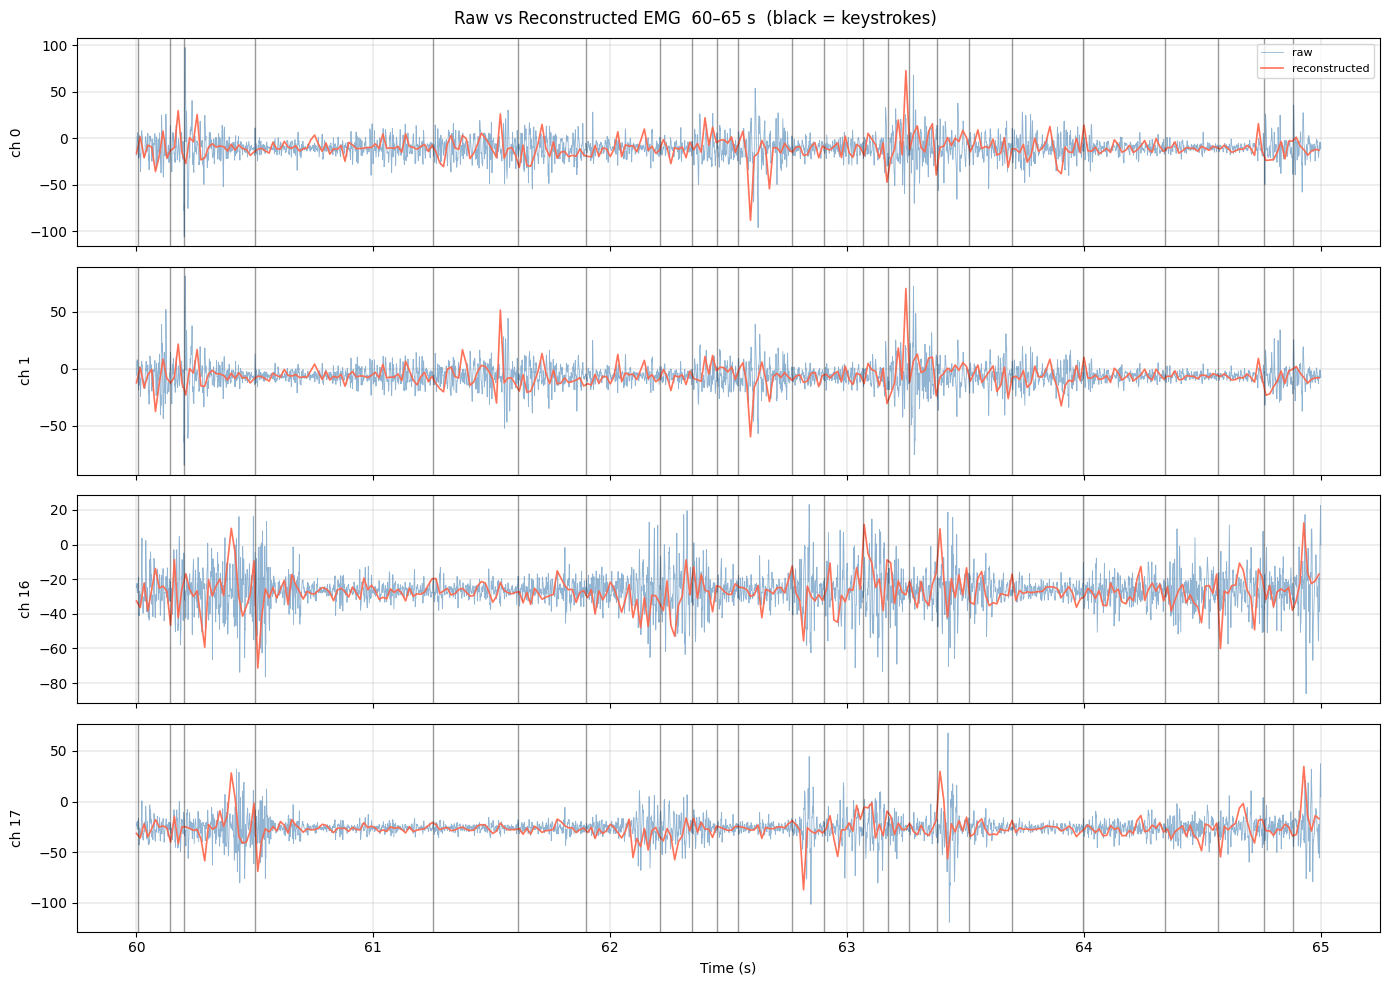

In [10]:
# Overlay: reconstructed vs raw EMG
from scipy.signal import butter, sosfiltfilt

SESSION_DIR = Path('89335547')
STEM = '2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f'

def bandpass(data, lo=0.0001, hi=500, fs=2000, order=4):
    sos = butter(order, [lo, hi], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, data, axis=0).astype(np.float32)

RAW_FILE = SESSION_DIR / f'{STEM}.hdf5'
with h5py.File(RAW_FILE) as f:
    ts        = f['emg2qwerty/timeseries']
    raw_time  = ts['time'][:]
    emg_left  = ts['emg_left'][:].astype(np.float32)
    emg_right = ts['emg_right'][:].astype(np.float32)

raw_emg    = np.concatenate([emg_left, emg_right], axis=1)          # (N, 32) original scale
raw_emg_bp = bandpass((raw_emg - norm_mean) / norm_std) * norm_std + norm_mean  # normalize → bandpass → denormalize

raw_rel_t = raw_time - raw_time[0]

# Use the same T_START / T_END / CH_SHOW as the zoom cell above
raw_mask = (raw_rel_t >= T_START) & (raw_rel_t <= T_END)

fig, axes = plt.subplots(len(CH_SHOW), 1,
                          figsize=(14, 2.5 * len(CH_SHOW)), sharex=True)
for ax, ch in zip(axes, CH_SHOW):
    ax.plot(raw_rel_t[raw_mask], raw_emg_bp[raw_mask, ch],
            lw=0.6, alpha=0.6, color='steelblue', label='raw')
    ax.plot(rel_t[win_mask], centre[win_mask, ch],
            lw=1.2, alpha=0.9, color='tomato', label='reconstructed')
    for k in ks_in:
        ax.axvline(k['start'] - times[0], color='k', lw=1.0, alpha=0.4)
    ax.set_ylabel(f'ch {ch}')
    ax.grid(True, lw=0.3)

axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw vs Reconstructed EMG  {T_START}–{T_END} s  (black = keystrokes)')
plt.tight_layout(); plt.show()

## 7. Batch Reconstruct All Sessions → Save `_recons_v3.hdf5`
Loop over all `_latent_v3.hdf5` files, decode using the per-session model, and write reconstructed EMG to `_recons_v3.hdf5`.

In [15]:
# Reconstruct all _latent_v3.hdf5 → _recons_v3.hdf5
SESSION_DIR  = Path('89335547')
latent_files = sorted(SESSION_DIR.glob('*_latent_v3.hdf5'))
print(f'Found {len(latent_files)} latent files\n')

BATCH = 512

for latent_file in latent_files:
    stem     = latent_file.stem.replace('_latent_v3', '')
    model_file = SESSION_DIR / f'{stem}_ae_v3.pt'
    raw_file   = SESSION_DIR / f'{stem}.hdf5'
    out_file   = SESSION_DIR / f'{stem}_recons_v3.hdf5'

    if out_file.exists():
        print(f'[skip] {out_file.name} already exists')
        continue

    if not model_file.exists():
        print(f'[skip] no model for {latent_file.name}')
        continue

    print(f'Processing {stem[:60]}...')

    # Load model
    ckpt = torch.load(model_file, map_location=device, weights_only=False)
    ae   = VanillaConv1dAE(latent_dim=ckpt['latent_dim'], window=ckpt['window']).to(device)
    ae.load_state_dict(ckpt['model_state_dict'])
    ae.eval()

    # Load latents
    with h5py.File(latent_file) as f:
        latents   = f['emg2qwerty/latent'][:]
        times     = f['emg2qwerty/time'][:]
        norm_mean = f['emg2qwerty/norm_mean'][:]
        norm_std  = f['emg2qwerty/norm_std'][:]

    # Decode
    recons_norm = []
    with torch.no_grad():
        for i in range(0, len(latents), BATCH):
            z   = torch.tensor(latents[i:i+BATCH], dtype=torch.float32).to(device)
            rec = ae.decode(z).cpu().numpy()
            recons_norm.append(rec)
    recons_norm = np.concatenate(recons_norm, axis=0)
    recons      = recons_norm * norm_std + norm_mean
    mid         = recons.shape[1] // 2
    centre      = recons[:, mid, :]   # (T, 32)

    # Save
    with h5py.File(out_file, 'w') as out_f:
        grp = out_f.create_group('emg2qwerty')
        with h5py.File(raw_file) as src:
            for k, v in src['emg2qwerty'].attrs.items():
                grp.attrs[k] = v
        grp.attrs['recons_source']  = latent_file.name
        grp.attrs['recons_rate_hz'] = float(2000 / 64)
        grp.attrs['recons_window']  = int(ckpt['window'])
        ts = grp.create_group('timeseries')
        ts.create_dataset('time',      data=times.astype(np.float64),  compression='gzip')
        ts.create_dataset('emg_left',  data=centre[:, :16].astype(np.float32), compression='gzip')
        ts.create_dataset('emg_right', data=centre[:, 16:].astype(np.float32), compression='gzip')

    print(f'  → {out_file.name}  shape={centre.shape}  rate=~{2000/64:.1f}Hz')

print('\nDone.')


Found 18 latent files

Processing 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4...
  → 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_recons_v3.hdf5  shape=(74275, 32)  rate=~31.2Hz
Processing 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4...
  → 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_recons_v3.hdf5  shape=(68037, 32)  rate=~31.2Hz
Processing 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4...
  → 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_recons_v3.hdf5  shape=(70377, 32)  rate=~31.2Hz
Processing 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4...
  → 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f_recons_v3.hdf5  shape=(58534, 32)  rate=~31.2Hz
Processing 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4...
  → 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-413

## 8. Overlay: Raw vs Reconstructed HDF5
Load a `_recons_v3.hdf5` file and plot raw vs reconstructed EMG channels to verify the saved reconstructions.

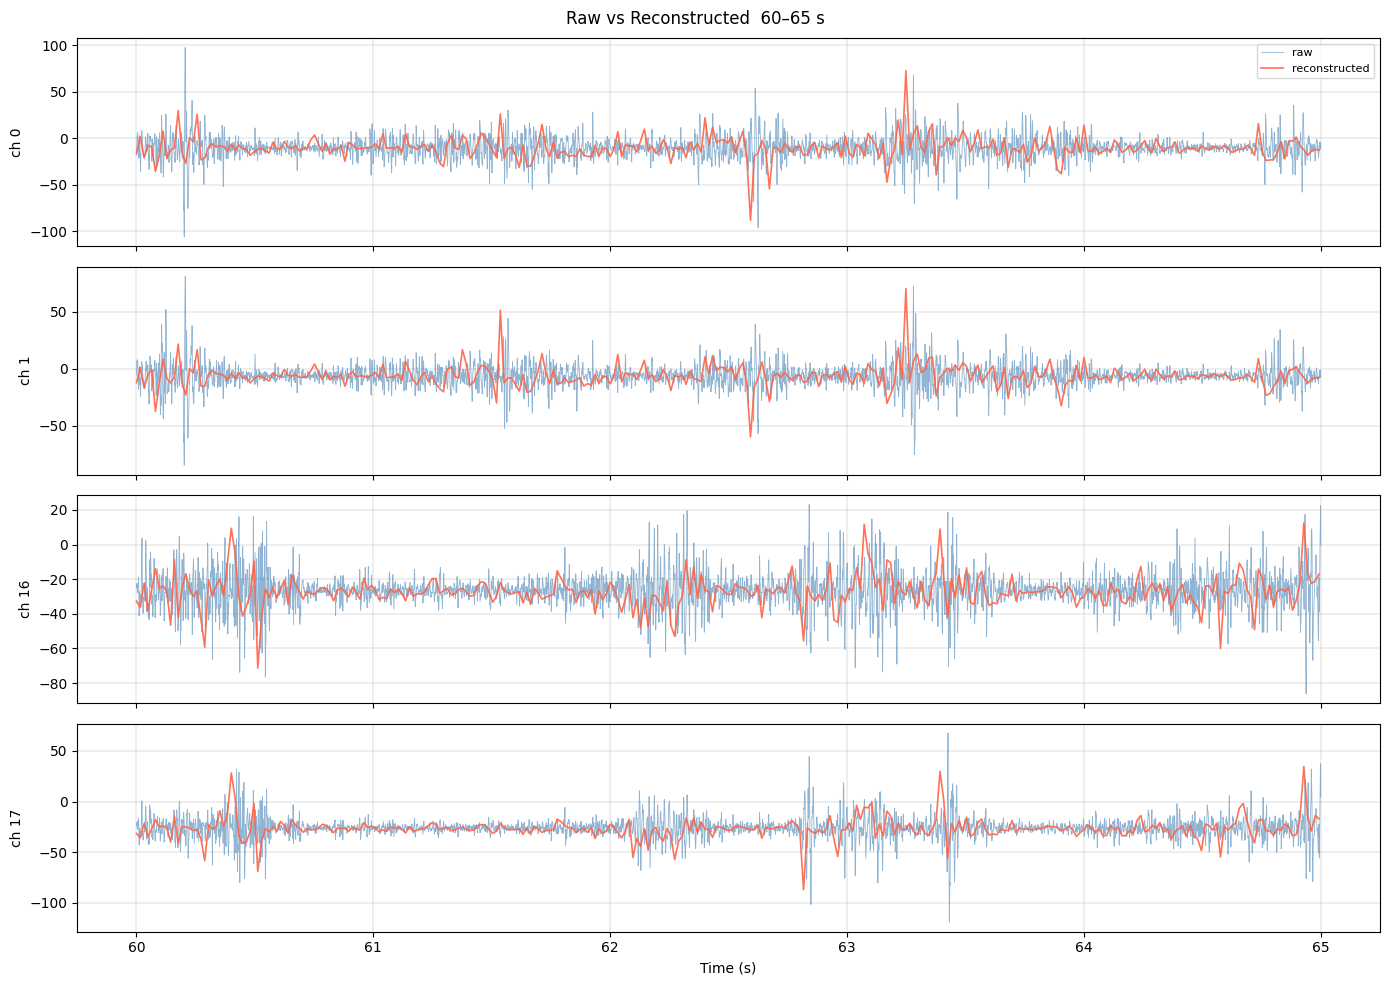

In [14]:
# Overlay: raw vs reconstructed HDF5
from scipy.signal import butter, sosfiltfilt

def bandpass(data, lo=0.0001, hi=500, fs=2000, order=4):
    sos = butter(order, [lo, hi], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, data, axis=0).astype(np.float32)

with h5py.File(RAW_FILE) as f:
    ts        = f['emg2qwerty/timeseries']      # compound dataset — index by field name
    raw_time  = ts['time'][:]
    emg_left  = ts['emg_left'][:].astype(np.float32)
    emg_right = ts['emg_right'][:].astype(np.float32)

with h5py.File(OUT_FILE) as f:
    rec_time  = f['emg2qwerty/timeseries/time'][:]
    rec_left  = f['emg2qwerty/timeseries/emg_left'][:]
    rec_right = f['emg2qwerty/timeseries/emg_right'][:]

raw_emg = np.concatenate([emg_left, emg_right], axis=1)
rec_emg = np.concatenate([rec_left,  rec_right],  axis=1)

raw_emg_bp = bandpass((raw_emg - norm_mean) / norm_std) * norm_std + norm_mean

raw_rel = raw_time - raw_time[0]
rec_rel = rec_time - raw_time[0]

T_START, T_END = 60, 65
CH_SHOW = [0, 1, 16, 17]

raw_mask = (raw_rel >= T_START) & (raw_rel <= T_END)
rec_mask = (rec_rel >= T_START) & (rec_rel <= T_END)

fig, axes = plt.subplots(len(CH_SHOW), 1, figsize=(14, 2.5 * len(CH_SHOW)), sharex=True)
for ax, ch in zip(axes, CH_SHOW):
    ax.plot(raw_rel[raw_mask], raw_emg_bp[raw_mask, ch],
            lw=0.6, alpha=0.6, color='steelblue', label='raw')
    ax.plot(rec_rel[rec_mask], rec_emg[rec_mask, ch],
            lw=1.2, alpha=0.9, color='tomato', label='reconstructed')
    ax.set_ylabel(f'ch {ch}')
    ax.grid(True, lw=0.3)

axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw vs Reconstructed  {T_START}–{T_END} s')
plt.tight_layout(); plt.show()
